[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/04_derivative_applications_optimization/first_principles.ipynb)

# Module 04 — Derivative Applications and Optimization

## 1. Why This Module Exists

The derivative is a purely local object. It is defined by a limit taken at one point, and on its
own it says nothing about the function anywhere else. Nothing in the definition of $f'(c)$ forbids
$f$ from doing whatever it likes at distance $1$ from $c$.

Yet almost every use of calculus is a global claim. "This loss has a unique minimizer." "This
function is increasing on the whole interval." "This iteration doubles its correct digits."
None of those statements is local.

One theorem closes that gap, and everything in this module is either a step toward it or a
consequence of it: the **Mean Value Theorem**. It converts a hypothesis about $f'$ on an interval
into an exact identity about the difference $f(b) - f(a)$. Once you have that identity, sign
information about $f'$ becomes monotonicity, sign information about $f''$ becomes convexity, a
ratio of derivatives becomes a limit of a ratio of functions, and a Taylor remainder becomes a
quaditative bound on the error of Newton's method.

The chain runs in one direction and is short. The Extreme Value Theorem gives a maximizer;
Fermat's theorem says a differentiable interior maximizer has vanishing derivative; Rolle's theorem
applies Fermat to a function with equal endpoints; the Mean Value Theorem applies Rolle after
subtracting the secant line; Cauchy's Mean Value Theorem is the two-function version; and
L'Hopital's rule is Cauchy's theorem read as a statement about limits. Nothing else is needed.

This module also collects the price of the theorem. Every one of its hypotheses is load-bearing,
and each failure is visible in a two-line counterexample: a corner destroys Rolle, a
non-indeterminate quotient destroys L'Hopital, a vanishing derivative destroys Newton.

## 2. Intuition

Draw the graph of a function over $[a, b]$ and draw the chord from $(a, f(a))$ to $(b, f(b))$.

Now slide a line of that same slope up and down the picture. If the graph is a smooth curve, the
sliding line has to touch the graph somewhere before it leaves — and at the moment of last contact
it is tangent. That contact point is the $c$ of the Mean Value Theorem. The average rate of change
over the whole interval is achieved as an instantaneous rate somewhere inside it.

The reason it must touch is the reason the whole chapter works: the vertical gap between graph and
chord is a continuous function that is zero at both ends, so it has an interior maximum or minimum,
and at that interior extremum its derivative vanishes. "Interior extremum" is where the topology
enters, and it is why the hypotheses are exactly continuity on the closed interval (so an extremum
exists) and differentiability on the open one (so the derivative exists where the extremum lands).

The second picture in this module is Newton's method. Replace the graph by its tangent line at the
current guess, solve the linear equation instead of the hard one, and repeat. The error of that
substitution is the Taylor remainder, which is quadratic in the step. That single fact — error
quadratic in step, and step comparable to error — is the whole of quadratic convergence.

Both pictures are the same picture: a curve and the straight line that pretends to be it.

The first code cell is the notebook preamble. It fixes the plotting defaults, seeds the single
random generator used anywhere in this notebook, and prints the machine epsilon that every later
residual claim is measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy import optimize
import sympy as sp

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")

machine epsilon = 2.2204e-16


Every residual reported later is quoted as a multiple of this number.

The next cell draws the two pictures described above, on the same function
$f(x) = x^3 - 3x$.

On the left: the chord over $[0, 3]$, the parallel tangent at the Mean Value Theorem point $c$, and
the vertical gap $g = f - L$ whose interior extremum produces $c$.

On the right: three Newton steps toward the root $r = \sqrt{3}$, each one replacing the curve by
its tangent line and reading off where that line crosses the axis.

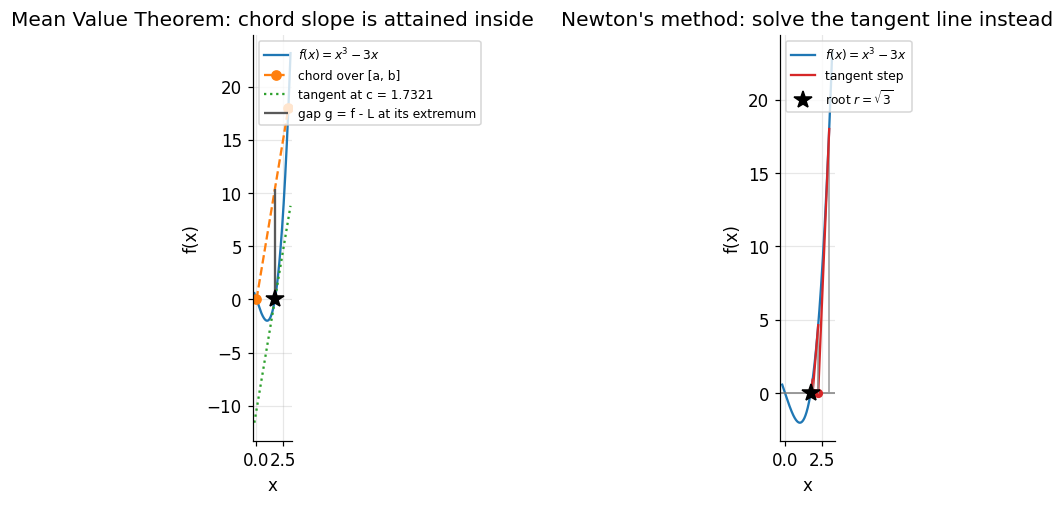

chord slope over [0, 3] = 6.0000000000   f'(c) = 6.0000000000
three Newton steps from x0 = 3 land at 1.745809828502, root = 1.732050807569


In [2]:
f = lambda t: t**3 - 3.0 * t
fp = lambda t: 3.0 * t**2 - 3.0

a, b = 0.0, 3.0
slope = (f(b) - f(a)) / (b - a)
c_mvt = np.sqrt((slope + 3.0) / 3.0)          # the positive root of 3c^2 - 3 = slope
xs = np.linspace(-0.2, 3.2, 600)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

axes[0].plot(xs, f(xs), color="tab:blue", label=r"$f(x) = x^3 - 3x$")
axes[0].plot([a, b], [f(a), f(b)], "o--", color="tab:orange", label="chord over [a, b]")
axes[0].plot(xs, f(c_mvt) + slope * (xs - c_mvt), ":", color="tab:green",
             label=f"tangent at c = {c_mvt:.4f}")
axes[0].vlines(c_mvt, f(c_mvt), f(a) + slope * (c_mvt - a), color="0.35",
               label="gap g = f - L at its extremum")
axes[0].plot([c_mvt], [f(c_mvt)], "k*", ms=12)
axes[0].set_title("Mean Value Theorem: chord slope is attained inside")

r = np.sqrt(3.0)
x_it = 3.0
axes[1].plot(xs, f(xs), color="tab:blue", label=r"$f(x) = x^3 - 3x$")
axes[1].axhline(0.0, color="0.5", lw=1)
for k in range(3):
    x_next = x_it - f(x_it) / fp(x_it)
    axes[1].plot([x_it, x_it], [0.0, f(x_it)], color="0.6", lw=1)
    axes[1].plot([x_it, x_next], [f(x_it), 0.0], "-", color="tab:red",
                 label="tangent step" if k == 0 else None)
    axes[1].plot([x_next], [0.0], "o", color="tab:red", ms=5)
    x_it = x_next
axes[1].plot([r], [0.0], "k*", ms=12, label=r"root $r=\sqrt{3}$")
axes[1].set_title("Newton's method: solve the tangent line instead")

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.legend(loc="upper left", fontsize=8)
plt.show()

print(f"chord slope over [0, 3] = {slope:.10f}   f'(c) = {fp(c_mvt):.10f}")
print(f"three Newton steps from x0 = 3 land at {x_it:.12f}, root = {r:.12f}")

The left panel shows the chord slope $6$ being reproduced exactly by the tangent slope at
$c = \sqrt{3} \approx 1.7321$, and the vertical bar marks the point where the gap $f - L$ is most
negative. The right panel shows three Newton steps carrying $x_0 = 3$ to twelve correct digits of
$\sqrt{3}$: the first step is coarse, the last is invisible at this scale. Sections 4 and 5 turn
both pictures into theorems.

## 3. Definitions

Throughout, $I \subseteq \mathbb{R}$ is an interval, $f : I \to \mathbb{R}$, and $\operatorname{int}(I)$
is the interior of $I$. Symbols follow [the notation register](../../docs/notation.md): a minimizer
is written $x^{\star}$, a step size is $\eta$, and $P_n$, $R_n$ are a Taylor polynomial and its
remainder.

### Definition 3.1 — Local and global extrema

$f$ has a **local maximum** at $c \in I$ when there is $\delta \gt 0$ with $f(x) \le f(c)$ for all
$x \in I$ with $\lvert x - c \rvert \lt \delta$; the maximum is **strict** when the inequality is
strict for $x \ne c$. A **local minimum** is the same with the inequality reversed, and a **local
extremum** is either. Dropping the $\delta$ and quantifying over all of $I$ gives the **global**
versions.

The $\delta$ is what makes the notion local: a local maximum is a statement about a
neighbourhood, and carries no information about the rest of $I$.

### Definition 3.2 — Critical point

$c \in I$ is a **critical point** of $f$ when either $f'(c) = 0$ or $f'(c)$ fails to exist.

Both cases must be admitted: $f(x) = \lvert x \rvert$ has a minimum at $0$ where no derivative
exists, so a search that only solves $f'(x) = 0$ can miss the answer.

### Definition 3.3 — Convex, strictly convex, concave

$f$ is **convex** on $I$ when for all $x_1, x_2 \in I$ and all $\lambda \in [0, 1]$

$$
f(\lambda x_1 + (1 - \lambda) x_2) \le \lambda f(x_1) + (1 - \lambda) f(x_2) .
$$

It is **strictly convex** when the inequality is strict whenever $x_1 \ne x_2$ and
$\lambda \in (0, 1)$, and **concave** when $-f$ is convex.

The definition mentions no derivative, which is what lets it apply to $\lvert x \rvert$ and to the
Huber loss. Theorem 4.8 supplies the derivative test when derivatives exist.

### Definition 3.4 — Inflection point

Let $f$ be continuous on $I$ and $c \in \operatorname{int}(I)$. The point $(c, f(c))$ is an
**inflection point** when there is $\delta \gt 0$ such that $f$ is convex on
$(c - \delta, c]$ and concave on $[c, c + \delta)$, or concave on $(c - \delta, c]$ and convex on
$[c, c + \delta)$.

The definition is about a *change* of convexity, not about the value of $f''(c)$. That distinction
is exactly what Example 6.2 in the exercises and Proposition 4.9(4) below turn on.

### Definition 3.5 — Indeterminate form

A quotient $f/g$ has an **indeterminate form** $0/0$ at $a$ when $f(x) \to 0$ and $g(x) \to 0$ as
$x \to a$, and the form $\infty/\infty$ when $\lvert f(x) \rvert \to \infty$ and
$\lvert g(x) \rvert \to \infty$.

"Indeterminate" is not a value; it is the statement that the limit laws for quotients do not apply,
so the limit is decided by *how* the two factors approach their limits and not by the limits alone.

### Definition 3.6 — Order of convergence

Let $x_k \to r$ with $e_k = x_k - r \ne 0$. The sequence converges with **order at least $p \ge 1$**
when there is $C \gt 0$ with

$$
\lvert e_{k+1} \rvert \le C \lvert e_k \rvert^{p}
$$

for all large $k$. Order $p = 1$ with $C \lt 1$ is **linear**, $p = 2$ is **quadratic**.

For $p = 1$ the constant must satisfy $C \lt 1$ or the bound is vacuous; for $p \gt 1$ any $C$ will
do once $\lvert e_k \rvert$ is small enough, which is why quadratic convergence is a purely local
statement.

## 4. Main Results

Theorems 4.1 to 4.4 are the chain that ends in the Mean Value Theorem, the result this module is
named after. Theorems 4.5 and 4.6 extend it to two functions and read the extension as a limit
rule. Theorems 4.7 to 4.9 are the consequences that make derivatives usable: monotonicity,
convexity, and the optimality conditions. Lemma 4.10 and Theorem 4.11 are the quantitative end of
the chapter, where the Mean Value Theorem becomes an error bound for Newton's method.

### Theorem 4.1 — Extreme Value Theorem

Let $f : [a, b] \to \mathbb{R}$ be continuous on the closed bounded interval $[a, b]$. Then there
exist $c_1, c_2 \in [a, b]$ with

$$
f(c_1) \le f(x) \le f(c_2) \qquad \text{for all } x \in [a, b] .
$$

*Continuity* is needed because $f(x) = x$ for $x \lt 1$, $f(1) = 0$ on $[0,1]$ attains no maximum.
*Closedness* is needed because $f(x) = x$ on $(0,1)$ attains neither. *Boundedness* is needed
because $f(x) = x$ on $[0, \infty)$ attains no maximum.

This is the one input the module takes from outside itself. It is proved in the prerequisite
module: [Module 02 — Limits and Continuity](../02_limits_and_continuity/first_principles.ipynb),
Theorem 4.7; see also Rudin, *Principles of Mathematical Analysis*, 3rd ed., Theorem 4.16, p. 89.

### Theorem 4.2 — Fermat's theorem on interior extrema

Let $f : I \to \mathbb{R}$, let $c \in \operatorname{int}(I)$ be a local extremum of $f$, and
suppose $f'(c)$ exists. Then

$$
f'(c) = 0 .
$$

*Interiority* is needed because the two one-sided difference quotients must both be available:
$f(x) = x$ on $[0,1]$ has a maximum at the endpoint $1$ with $f'(1) = 1$.
*Existence of $f'(c)$* is needed because $f(x) = -\lvert x \rvert$ has a maximum at $0$ and no
derivative there.

The converse is false: $f'(0) = 0$ for $f(x) = x^3$, which has no extremum at $0$. Theorem 4.2 is a
filter, not a test.

### Theorem 4.3 — Rolle's theorem

Let $f : [a, b] \to \mathbb{R}$ with $a \lt b$ satisfy

1. $f$ continuous on $[a, b]$,
2. $f$ differentiable on $(a, b)$,
3. $f(a) = f(b)$.

Then there is $c \in (a, b)$ with $f'(c) = 0$.

*Continuity on the closed interval* is what lets Theorem 4.1 produce an extremum at all.
*Differentiability on the open interval* is what lets Theorem 4.2 act at that extremum; the corner
of $f(x) = 1 - \lvert x \rvert$ on $[-1, 1]$ shows the conclusion fails without it.
*Equal endpoints* is what forces the extremum inward: without it $f(x) = x$ on $[0,1]$ is a
counterexample.

### Theorem 4.4 — Mean Value Theorem

Let $f : [a, b] \to \mathbb{R}$ with $a \lt b$ be continuous on $[a, b]$ and differentiable on
$(a, b)$. Then there is $c \in (a, b)$ with

$$
\boxed{\, f'(c) = \frac{f(b) - f(a)}{b - a} \,}
$$

**Interpretation.** The average rate of change over $[a,b]$ — a global quantity, computed from two
function values — is *exactly equal* to the instantaneous rate at some interior point. Read from
right to left it is an existence statement about $c$; read from left to right, as
$f(b) - f(a) = f'(c)(b-a)$, it is the tool that converts any pointwise bound on $f'$ into a bound
on the increment of $f$, which is how every monotonicity, convexity, and error estimate in this
module is obtained.

The hypotheses are those of Theorem 4.3, and are needed for the same reasons: continuity on
$[a,b]$ to get an extremum, differentiability on $(a,b)$ to differentiate there. The point $c$ need
not be unique, and the theorem gives no way to locate it.

### Theorem 4.5 — Cauchy's Mean Value Theorem

Let $f, g : [a, b] \to \mathbb{R}$ be continuous on $[a, b]$ and differentiable on $(a, b)$, and
suppose $g'(x) \ne 0$ for every $x \in (a, b)$. Then $g(b) \ne g(a)$, and there is $c \in (a, b)$
with

$$
\boxed{\, \frac{f'(c)}{g'(c)} = \frac{f(b) - f(a)}{g(b) - g(a)} \,}
$$

**Interpretation.** Two functions traversed over the same interval realise the ratio of their total
increments as the ratio of their instantaneous rates at one common interior point. The single
shared $c$ is the whole content: applying Theorem 4.4 to $f$ and to $g$ separately gives two
different points and no usable identity, which is exactly why L'Hopital's rule needs this version
and not the previous one.

*Non-vanishing $g'$* is needed twice: to keep the right-hand denominator non-zero (via Theorem 4.3
applied to $g$) and to keep the left-hand one non-zero. Taking $g(x) = x$ recovers Theorem 4.4.

### Theorem 4.6 — L'Hopital's rule, form $0/0$

Let $a \in \mathbb{R}$, let $f, g$ be differentiable on $(a, a + \delta)$ for some $\delta \gt 0$
with $g'(x) \ne 0$ there, and suppose

1. $\lim_{x \to a^+} f(x) = 0$ and $\lim_{x \to a^+} g(x) = 0$,
2. $\lim_{x \to a^+} \dfrac{f'(x)}{g'(x)} = L \in \mathbb{R} \cup \lbrace -\infty, +\infty \rbrace$.

Then

$$
\lim_{x \to a^+} \frac{f(x)}{g(x)} = L .
$$

The same statement holds for $x \to a^-$, and hence for two-sided limits when both hold.

*Hypothesis 1* is what allows $f$ and $g$ to be extended continuously by $f(a) = g(a) = 0$, which is
what makes the quotient of increments equal to the quotient of values.
*The non-vanishing of $g'$* is what makes Theorem 4.5 applicable on every $[a, x]$.
*Hypothesis 2* is a genuine hypothesis, not a conclusion: if $f'/g'$ has no limit the rule says
nothing, and $f(x) = x + \sin x$, $g(x) = x$ as $x \to \infty$ show that $f/g$ can converge anyway.

### Theorem 4.7 — Monotonicity criterion

Let $f$ be continuous on $[a, b]$ and differentiable on $(a, b)$.

1. If $f'(x) \gt 0$ for all $x \in (a, b)$, then $f$ is strictly increasing on $[a, b]$.
2. If $f'(x) \lt 0$ for all $x \in (a, b)$, then $f$ is strictly decreasing on $[a, b]$.
3. If $f'(x) = 0$ for all $x \in (a, b)$, then $f$ is constant on $[a, b]$.
4. $f$ is non-decreasing on $[a, b]$ if and only if $f'(x) \ge 0$ for all $x \in (a, b)$.

*Continuity on the closed interval* is what extends the conclusion to the endpoints.
Only 4 is an equivalence: the converse of 1 is false, since $f(x) = x^3$ is strictly increasing on
$[-1, 1]$ with $f'(0) = 0$.

### Theorem 4.8 — Second-derivative test for convexity

Let $f$ be differentiable on the open interval $(a, b)$.

1. $f$ is convex on $(a, b)$ if and only if $f'$ is non-decreasing on $(a, b)$.
2. If in addition $f$ is twice differentiable, $f$ is convex on $(a, b)$ if and only if
   $f''(x) \ge 0$ for all $x \in (a, b)$.
3. If $f''(x) \gt 0$ for all $x \in (a, b)$, then $f$ is strictly convex on $(a, b)$.

*Differentiability* is needed for 1 to be stated at all; convexity itself needs none
(Definition 3.3). Part 3 is one-directional: $f(x) = x^4$ is strictly convex on $\mathbb{R}$ but
$f''(0) = 0$.

### Theorem 4.9 — Optimality conditions in one dimension

Let $x^{\star} \in \operatorname{int}(I)$.

1. **(First-order necessary.)** If $f$ is differentiable at $x^{\star}$ and $x^{\star}$ is a local
   extremum, then $f'(x^{\star}) = 0$.
2. **(Second-order necessary.)** If $f$ is twice differentiable on a neighbourhood of $x^{\star}$
   with $f''$ continuous at $x^{\star}$, and $x^{\star}$ is a local minimum, then
   $f'(x^{\star}) = 0$ and $f''(x^{\star}) \ge 0$.
3. **(Second-order sufficient.)** If $f$ is twice differentiable on a neighbourhood of $x^{\star}$
   with $f''$ continuous at $x^{\star}$, and $f'(x^{\star}) = 0$ with $f''(x^{\star}) \gt 0$, then
   $x^{\star}$ is a strict local minimum. With $f''(x^{\star}) \lt 0$ it is a strict local maximum.
4. **(Global.)** If $f$ is convex on the interval $I$ and differentiable at
   $x^{\star} \in \operatorname{int}(I)$ with $f'(x^{\star}) = 0$, then $x^{\star}$ is a global
   minimizer of $f$ on $I$; if $f$ is strictly convex the minimizer is unique.

*Interiority* is required in every part, for the reason given under Theorem 4.2.
*Continuity of $f''$ at $x^{\star}$* is what upgrades the sign of $f''(x^{\star})$ into a sign on a
whole neighbourhood, which is what part 3 actually uses.
The gap between 2 and 3 is real and cannot be closed: $f(x) = x^3$ has $f'(0) = f''(0) = 0$ and no
extremum, while $f(x) = x^4$ has $f'(0) = f''(0) = 0$ and a strict minimum.

### Lemma 4.10 — Taylor's theorem with Lagrange remainder, order one

Let $f$ be differentiable on an open interval $J$ with $f'$ differentiable on $J$, and let
$x, y \in J$ with $x \ne y$. Then there is $\xi$ strictly between $x$ and $y$ with

$$
f(y) = f(x) + f'(x)(y - x) + \frac{f''(\xi)}{2}(y - x)^2 .
$$

*Twice differentiability* is what supplies the second derivative in the remainder; with only $f'$
available the remainder is $o(y-x)$ and no quadratic bound follows. The lemma is stated and proved
here, at order one, so that Theorem 4.11 does not depend on the general Taylor theorem of
[Module 09](../09_taylor_and_power_series/first_principles.ipynb); the proof is three lines from
Theorem 4.3.

### Theorem 4.11 — Local quadratic convergence of Newton's method

Let $f$ be twice differentiable on an open interval containing $r$, with

1. $f(r) = 0$,
2. $f'(r) \ne 0$,
3. $f''$ bounded on a neighbourhood of $r$.

Then there is $\rho \gt 0$ and $C \gt 0$ with $C\rho \lt 1$ such that for every
$x_0 \in N = (r - \rho, r + \rho)$ the Newton iterates

$$
x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}
$$

stay in $N$, converge to $r$, and satisfy

$$
\boxed{\, \lvert x_{k+1} - r \rvert \le C \, \lvert x_k - r \rvert^{2} \,}
$$

**Interpretation.** Once the iterate is inside $N$, the error is squared at every step, so the
number of correct digits doubles per iteration and the cost of the last digit is the same as the
cost of the first. The consequence is a sharp division of labour: Newton's method is a *finisher*,
not a *starter*. Every hypothesis is local and none of them is checkable from $x_0$ alone, which is
why practical solvers wrap Newton in a globalization — a bracketing phase, or the damped step
$x_{k+1} = x_k + \eta_k d_k$ of Section 8.

*Simplicity of the root ($f'(r) \ne 0$)* is essential: at a double root the method converges only
linearly, with $\lvert e_{k+1} \rvert \approx \tfrac12 \lvert e_k \rvert$.
*Boundedness of $f''$* supplies the constant $C = M/(2m)$.
*"Sufficiently close"* is not removable: for $f(x) = x^3 - 5x$ the start $x_0 = 1$ produces the
2-cycle $1 \mapsto -1 \mapsto 1$ and never converges.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.2)

Assume $c$ is a local maximum; the minimum case follows by applying the result to $-f$.

Choose $\delta \gt 0$ with $(c - \delta, c + \delta) \subseteq I$ and $f(x) \le f(c)$ for all
$x$ in that interval, so that $f(c + h) - f(c) \le 0$ whenever $\lvert h \rvert \lt \delta$.

For $0 \lt h \lt \delta$ the quotient has a non-positive numerator and a positive denominator, so

$$
\frac{f(c+h) - f(c)}{h} \le 0 \quad \Longrightarrow \quad
\lim_{h \to 0^+} \frac{f(c+h) - f(c)}{h} \le 0 .
$$

For $-\delta \lt h \lt 0$ the denominator is negative, so

$$
\frac{f(c+h) - f(c)}{h} \ge 0 \quad \Longrightarrow \quad
\lim_{h \to 0^-} \frac{f(c+h) - f(c)}{h} \ge 0 .
$$

Because $f'(c)$ exists, both one-sided limits exist and equal $f'(c)$. Hence
$0 \le f'(c) \le 0$, so $f'(c) = 0$. $\blacksquare$

### Proof 5.2 (of Theorem 4.3)

By hypothesis 1 and Theorem 4.1, $f$ attains a maximum $M = f(c_2)$ and a minimum $m = f(c_1)$ on
$[a, b]$.

*Case $M = m$.* Then $f$ is constant, and $f'(c) = 0$ for every $c \in (a, b)$.

*Case $M \gt m$.* Since $f(a) = f(b)$ by hypothesis 3, the common endpoint value $f(a)$ cannot equal
both $M$ and $m$. If $M \ne f(a)$, then no point where $f$ takes the value $M$ is an endpoint, so
$c_2 \in (a, b)$; otherwise $m \ne f(a)$ and likewise $c_1 \in (a, b)$. Either way $f$ has a local
extremum at an interior point $c$.

By hypothesis 2, $f'(c)$ exists, so Theorem 4.2 gives $f'(c) = 0$. $\blacksquare$

### Proof 5.3 (of Theorem 4.4)

Define the secant line and the gap

$$
L(x) = f(a) + \frac{f(b) - f(a)}{b - a}(x - a), \qquad g(x) = f(x) - L(x) .
$$

$g$ is continuous on $[a, b]$ and differentiable on $(a, b)$, since $f$ is and $L$ is a polynomial.
At the endpoints,

$$
g(a) = f(a) - f(a) = 0, \qquad
g(b) = f(b) - f(a) - \frac{f(b) - f(a)}{b - a}(b - a) = 0 ,
$$

so $g(a) = g(b)$ and $g$ satisfies all three hypotheses of Theorem 4.3. Therefore there is
$c \in (a, b)$ with $g'(c) = 0$, that is

$$
f'(c) - \frac{f(b) - f(a)}{b - a} = 0 ,
$$

which is the claim. $\blacksquare$

### Proof 5.4 (of Theorem 4.5)

First, $g(b) \ne g(a)$: if they were equal, $g$ would satisfy the hypotheses of Theorem 4.3 and
some $x \in (a, b)$ would have $g'(x) = 0$, contradicting the hypothesis $g' \ne 0$ on $(a, b)$.

Define

$$
h(x) = [f(b) - f(a)]\,[g(x) - g(a)] - [g(b) - g(a)]\,[f(x) - f(a)] .
$$

$h$ is continuous on $[a, b]$ and differentiable on $(a, b)$ as a linear combination of $f$ and $g$.
Evaluating,

$$
h(a) = 0, \qquad h(b) = [f(b) - f(a)][g(b) - g(a)] - [g(b) - g(a)][f(b) - f(a)] = 0 .
$$

By Theorem 4.3 there is $c \in (a, b)$ with

$$
h'(c) = [f(b) - f(a)]\, g'(c) - [g(b) - g(a)]\, f'(c) = 0 .
$$

Both $g'(c) \ne 0$ and $g(b) - g(a) \ne 0$, so dividing by $g'(c)[g(b) - g(a)]$ gives the stated
identity. $\blacksquare$

### Proof 5.5 (of Theorem 4.6)

Extend $f$ and $g$ to $[a, a + \delta)$ by setting $f(a) = g(a) = 0$. Hypothesis 1 makes both
extensions continuous at $a$, and they are already continuous on $(a, a + \delta)$ because they are
differentiable there.

Fix $x \in (a, a + \delta)$. On $[a, x]$ the pair $f, g$ satisfies every hypothesis of Theorem 4.5:
continuity on the closed interval, differentiability on the open one, and $g' \ne 0$ throughout.
Hence there is $c_x \in (a, x)$ with

$$
\frac{f(x)}{g(x)} = \frac{f(x) - f(a)}{g(x) - g(a)} = \frac{f'(c_x)}{g'(c_x)} .
$$

Theorem 4.5 also guarantees $g(x) - g(a) = g(x) \ne 0$, so the left-hand side is defined.

Now let $\varepsilon \gt 0$. By hypothesis 2 there is $\delta_1 \in (0, \delta)$ with
$\lvert f'(t)/g'(t) - L \rvert \lt \varepsilon$ for all $t \in (a, a + \delta_1)$. For any
$x \in (a, a + \delta_1)$ the point $c_x$ satisfies $a \lt c_x \lt x \lt a + \delta_1$, so it lies in
that same interval and

$$
\left\lvert \frac{f(x)}{g(x)} - L \right\rvert
= \left\lvert \frac{f'(c_x)}{g'(c_x)} - L \right\rvert \lt \varepsilon .
$$

Since $\varepsilon$ was arbitrary, $\lim_{x \to a^+} f(x)/g(x) = L$. The case $L = \pm\infty$ is the
same argument with "$\lt \varepsilon$" replaced by "$\gt K$" for arbitrary $K$. The left-hand limit
is symmetric. $\blacksquare$

### Proof 5.6 (of Theorem 4.7)

*Part 1.* Let $a \le x_1 \lt x_2 \le b$. On $[x_1, x_2]$ the function $f$ is continuous and it is
differentiable on $(x_1, x_2) \subseteq (a, b)$, so Theorem 4.4 gives $c \in (x_1, x_2)$ with

$$
f(x_2) - f(x_1) = f'(c)\,(x_2 - x_1) .
$$

The right-hand side is a product of two positive numbers, so $f(x_1) \lt f(x_2)$.

*Part 2* follows by applying part 1 to $-f$, and *part 3* by noting that the same identity gives
$f(x_2) - f(x_1) = 0$ for every pair.

*Part 4.* If $f' \ge 0$ the identity gives $f(x_2) - f(x_1) \ge 0$. Conversely, if $f$ is
non-decreasing then every difference quotient $\bigl(f(x + h) - f(x)\bigr)/h$ is non-negative — for
$h$ of either sign — so its limit $f'(x)$ is non-negative. $\blacksquare$

### Proof 5.7 (of Theorem 4.8)

*Part 1, direction $\Leftarrow$.* Assume $f'$ is non-decreasing. Let $x_1 \lt x_2$ in $(a,b)$,
$\lambda \in (0,1)$, and set $x_\lambda = \lambda x_1 + (1-\lambda) x_2$, so
$x_1 \lt x_\lambda \lt x_2$. By Theorem 4.4 on $[x_1, x_\lambda]$ and on $[x_\lambda, x_2]$ there
are $c_1 \in (x_1, x_\lambda)$ and $c_2 \in (x_\lambda, x_2)$ with

$$
\frac{f(x_\lambda) - f(x_1)}{x_\lambda - x_1} = f'(c_1),
\qquad
\frac{f(x_2) - f(x_\lambda)}{x_2 - x_\lambda} = f'(c_2) .
$$

Since $c_1 \lt x_\lambda \lt c_2$ and $f'$ is non-decreasing, $f'(c_1) \le f'(c_2)$, hence

$$
\frac{f(x_\lambda) - f(x_1)}{x_\lambda - x_1} \le \frac{f(x_2) - f(x_\lambda)}{x_2 - x_\lambda} .
$$

Now $x_\lambda - x_1 = (1-\lambda)(x_2 - x_1)$ and $x_2 - x_\lambda = \lambda (x_2 - x_1)$; both are
positive, so cross-multiplying is legitimate and yields

$$
\lambda \bigl( f(x_\lambda) - f(x_1) \bigr) \le (1-\lambda) \bigl( f(x_2) - f(x_\lambda) \bigr) ,
$$

that is $f(x_\lambda) \le \lambda f(x_1) + (1-\lambda) f(x_2)$, which is Definition 3.3.

*Part 1, direction $\Rightarrow$.* Assume $f$ convex and let $x_1 \lt x_2$ in $(a,b)$. For
$t \in (0,1)$ write $u = x_1 + t(x_2 - x_1)$. Convexity applied to the pair $x_1, x_2$ gives
$f(u) \le (1-t) f(x_1) + t f(x_2)$, and rearranging in two ways gives the two chord inequalities

$$
\frac{f(u) - f(x_1)}{u - x_1} \le \frac{f(x_2) - f(x_1)}{x_2 - x_1}
\le \frac{f(x_2) - f(u)}{x_2 - u} .
$$

Letting $t \to 0^+$ in the left inequality gives $f'(x_1) \le \frac{f(x_2)-f(x_1)}{x_2-x_1}$, and
letting $t \to 1^-$ in the right one gives $\frac{f(x_2)-f(x_1)}{x_2-x_1} \le f'(x_2)$. Hence
$f'(x_1) \le f'(x_2)$.

*Part 2.* By Theorem 4.7(4) applied to $f'$ in place of $f$, the derivative $f'$ is non-decreasing
on $(a,b)$ if and only if $f'' \ge 0$ there. Combining with part 1 gives the equivalence.

*Part 3.* If $f'' \gt 0$ then Theorem 4.7(1) applied to $f'$ makes $f'$ **strictly** increasing, so
$f'(c_1) \lt f'(c_2)$ in the $\Leftarrow$ argument above and every inequality in it becomes strict,
giving $f(x_\lambda) \lt \lambda f(x_1) + (1-\lambda) f(x_2)$. $\blacksquare$

### Proof 5.8 (of Theorem 4.9)

*Part 1* is Theorem 4.2.

*Part 2.* Suppose $x^{\star}$ is a local minimum and $f''(x^{\star}) \lt 0$. By continuity of $f''$
at $x^{\star}$ there is $\delta \gt 0$ with $f'' \lt 0$ on $(x^{\star}-\delta, x^{\star}+\delta)$,
so by Theorem 4.7(2) applied to $f'$ the derivative $f'$ is strictly decreasing there. Since
$f'(x^{\star}) = 0$ by part 1, $f' \gt 0$ to the left of $x^{\star}$ and $f' \lt 0$ to the right, so
by Theorem 4.7 $f$ is strictly increasing then strictly decreasing: $x^{\star}$ is a strict local
*maximum*, and since $f$ is not constant near $x^{\star}$ it is not a local minimum. Contradiction,
so $f''(x^{\star}) \ge 0$.

*Part 3.* Assume $f'(x^{\star}) = 0$ and $f''(x^{\star}) \gt 0$. By continuity of $f''$ there is
$\delta \gt 0$ with $f'' \gt 0$ on $J = (x^{\star}-\delta, x^{\star}+\delta)$. By Theorem 4.7(1)
applied to $f'$, $f'$ is strictly increasing on $J$, so $f' \lt 0$ on $(x^{\star}-\delta, x^{\star})$
and $f' \gt 0$ on $(x^{\star}, x^{\star}+\delta)$. Theorem 4.7 then makes $f$ strictly decreasing on
$(x^{\star}-\delta, x^{\star}]$ and strictly increasing on $[x^{\star}, x^{\star}+\delta)$, so
$f(x) \gt f(x^{\star})$ for every $x \in J$ with $x \ne x^{\star}$: a strict local minimum. The
maximum case is the same argument applied to $-f$.

*Part 4.* Let $f$ be convex on $I$ with $f'(x^{\star}) = 0$, and let $y \in I$ with $y \ne x^{\star}$.
By part 1 of Theorem 4.8, $f'$ is non-decreasing on $\operatorname{int}(I)$. Take $y \gt x^{\star}$
(the other case is symmetric). By Theorem 4.4 on $[x^{\star}, y]$ there is
$c \in (x^{\star}, y)$ with $f(y) - f(x^{\star}) = f'(c)(y - x^{\star})$, and
$f'(c) \ge f'(x^{\star}) = 0$ because $c \gt x^{\star}$. Hence $f(y) \ge f(x^{\star})$, so
$x^{\star}$ is a global minimizer. If $f$ is strictly convex then $f'$ is strictly increasing, so
$f'(c) \gt 0$ and $f(y) \gt f(x^{\star})$, giving uniqueness. $\blacksquare$

### Proof 5.9 (of Lemma 4.10)

Fix $x \ne y$ in $J$ and choose the number $K$ so that

$$
f(y) = f(x) + f'(x)(y - x) + \frac{K}{2}(y - x)^2 ,
$$

which is possible and determines $K$ uniquely because $(y-x)^2 \ne 0$. Define, for $t$ in the closed
interval with endpoints $x$ and $y$,

$$
\varphi(t) = f(y) - f(t) - f'(t)(y - t) - \frac{K}{2}(y - t)^2 .
$$

$\varphi$ is differentiable on that interval because $f$ and $f'$ are, and

$$
\varphi(y) = 0, \qquad \varphi(x) = 0
$$

— the first by inspection, the second by the choice of $K$. By Theorem 4.3 there is $\xi$ strictly
between $x$ and $y$ with $\varphi'(\xi) = 0$. Differentiating and cancelling the two $f'(t)$ terms,

$$
\varphi'(t) = -f''(t)(y - t) + K (y - t) = (y - t)\,\bigl( K - f''(t) \bigr) .
$$

Since $\xi$ is strictly between $x$ and $y$ we have $y - \xi \ne 0$, so $\varphi'(\xi) = 0$ forces
$K = f''(\xi)$. Substituting back into the defining equation for $K$ gives the lemma.
$\blacksquare$

### Proof 5.10 (of Theorem 4.11)

By hypothesis 2 and hypothesis 3 there are $\rho_0 \gt 0$, $m \gt 0$ and $M \ge 0$ with

$$
\lvert f'(x) \rvert \ge m , \qquad \lvert f''(x) \rvert \le M
\qquad \text{for all } x \in (r - \rho_0, r + \rho_0) ;
$$

the lower bound on $\lvert f' \rvert$ exists because $f'$ is continuous — it is differentiable — and
$f'(r) \ne 0$. Set $C = M/(2m)$ if $M \gt 0$, and pick

$$
\rho = \min\Bigl\lbrace \rho_0, \tfrac{1}{2C} \Bigr\rbrace , \qquad N = (r - \rho, r + \rho) ,
$$

so that $C\rho \le 1/2 \lt 1$. (If $M = 0$ then $f$ is affine and Newton reaches $r$ in one step.)

*One step.* Let $x_k \in N$. Apply Lemma 4.10 with $x = x_k$, $y = r$: there is $\xi_k$ strictly
between $x_k$ and $r$ — hence in $N$ — with

$$
0 = f(r) = f(x_k) + f'(x_k)(r - x_k) + \frac{f''(\xi_k)}{2}(r - x_k)^2 .
$$

Since $x_k \in N$, $f'(x_k) \ne 0$, so the Newton step is defined; divide by $f'(x_k)$ and use
$f(x_k)/f'(x_k) = x_k - x_{k+1}$:

$$
0 = (x_k - x_{k+1}) - (x_k - r) + \frac{f''(\xi_k)}{2 f'(x_k)} (x_k - r)^2 .
$$

Writing $e_k = x_k - r$ and rearranging,

$$
e_{k+1} = \frac{f''(\xi_k)}{2 f'(x_k)}\, e_k^2 ,
\qquad\text{so}\qquad
\lvert e_{k+1} \rvert \le \frac{M}{2m} \lvert e_k \rvert^2 = C \lvert e_k \rvert^2 .
$$

*Invariance and convergence.* If $x_k \in N$ then $\lvert e_k \rvert \lt \rho$ and

$$
\lvert e_{k+1} \rvert \le C \lvert e_k \rvert^2 = (C \lvert e_k \rvert)\lvert e_k \rvert
\lt (C\rho) \lvert e_k \rvert \lt \lvert e_k \rvert \lt \rho ,
$$

so $x_{k+1} \in N$ too. By induction every iterate from $x_0 \in N$ remains in $N$, and iterating the
displayed inequality gives $\lvert e_k \rvert \lt (C\rho)^k \rho \to 0$. Hence $x_k \to r$ with

$$
\lvert e_{k+1} \rvert \le C \lvert e_k \rvert^2 ,
$$

which is order $2$ in the sense of Definition 3.6. $\blacksquare$

## 6. Worked Examples

Each example is small enough to finish by hand; the code cell after it recomputes the same numbers
and asserts agreement.

### Example 6.1 (of Theorem 4.4) — the Mean Value point of a cubic

Take $f(x) = x^3 - 3x$ on $[0, 3]$. It is a polynomial, so continuous on $[0,3]$ and
differentiable on $(0,3)$.

Endpoint values: $f(0) = 0$ and $f(3) = 27 - 9 = 18$. The chord slope is

$$
\frac{f(3) - f(0)}{3 - 0} = \frac{18 - 0}{3} = 6 .
$$

Solve $f'(c) = 3c^2 - 3 = 6$, i.e. $c^2 = 3$, so $c = \pm\sqrt{3}$. Only $c = \sqrt{3} \approx
1.7320508$ lies in $(0, 3)$.

Check: $f(\sqrt{3}) = 3\sqrt{3} - 3\sqrt{3} = 0$, and the tangent there is
$y = 6(x - \sqrt{3})$, which is parallel to the chord $y = 6x$ and sits $6\sqrt{3} \approx 10.392$
below it.

The cell below recomputes the chord slope, solves for $c$ symbolically, and checks the Mean Value
identity to machine precision.

In [3]:
x = sp.symbols("x")
f_sym = x**3 - 3 * x
a_e, b_e = 0, 3
chord = sp.Rational(f_sym.subs(x, b_e) - f_sym.subs(x, a_e), b_e - a_e)
sols = sp.solve(sp.Eq(sp.diff(f_sym, x), chord), x)
inside = [s for s in sols if a_e < s < b_e]
print("chord slope :", chord)
print("solutions of f'(c) = chord :", sols, "  inside (0,3):", inside)

c_val = float(inside[0])
resid = (3 * c_val**2 - 3) - 6.0
print(f"c = {c_val:.12f}   sqrt(3) = {np.sqrt(3.0):.12f}")
print(f"MVT residual f'(c) - chord = {resid:.3e}  ({abs(resid) / EPS:.1f} x machine epsilon)")
assert abs(resid) < 16 * EPS

chord slope : 6
solutions of f'(c) = chord : [-sqrt(3), sqrt(3)]   inside (0,3): [sqrt(3)]
c = 1.732050807569   sqrt(3) = 1.732050807569
MVT residual f'(c) - chord = -1.776e-15  (8.0 x machine epsilon)


The symbolic solve returns $\pm\sqrt{3}$ and only $+\sqrt{3}$ survives the interior test, matching
the hand computation. The residual is a small multiple of machine epsilon, so the identity of
Theorem 4.4 holds exactly up to floating-point rounding.

### Example 6.2 (of Theorem 4.6) — an indeterminate quotient done twice

Evaluate $\lim_{x \to 0} \dfrac{1 - \cos x}{x^2}$.

Both $1 - \cos x \to 0$ and $x^2 \to 0$, so the form is $0/0$ (Definition 3.5) and hypothesis 1 of
Theorem 4.6 holds. On any punctured interval around $0$, $g'(x) = 2x \ne 0$.

First application:

$$
\frac{f'(x)}{g'(x)} = \frac{\sin x}{2x} .
$$

This is again $0/0$, with $g''(x) = 2 \ne 0$. Second application:

$$
\frac{f''(x)}{g''(x)} = \frac{\cos x}{2} \xrightarrow[x \to 0]{} \frac{1}{2} .
$$

Hypothesis 2 now holds for the inner quotient, so $\sin x / (2x) \to 1/2$, and hypothesis 2 then
holds for the outer one, so the original limit is $\tfrac{1}{2}$.

Cross-check without L'Hopital: $1 - \cos x = \tfrac{x^2}{2} - \tfrac{x^4}{24} + \cdots$, so the
quotient is $\tfrac12 - \tfrac{x^2}{24} + \cdots$. At $x = 0.1$ the prediction is
$0.5 - 0.01/24 \approx 0.4995833\overline{3}$, and the residual gap should be the next term
$x^4/720$.

The cell below evaluates the limit symbolically, prints the numeric quotient at shrinking $x$, and
compares it with the series prediction.

In [4]:
lim_val = sp.limit((1 - sp.cos(x)) / x**2, x, 0)
print("sympy limit:", lim_val)

hs = np.array([0.5, 0.2, 0.1])
quot = (1.0 - np.cos(hs)) / hs**2
pred = 0.5 - hs**2 / 24.0
gap = np.abs(quot - pred)
for xv, q, pv, gv in zip(hs, quot, pred, gap):
    print(f"x = {xv:4.2f}   quotient {q:.10f}   series 1/2 - x^2/24 {pv:.10f}"
          f"   gap {gv:.3e}   next term x^4/720 {xv**4 / 720:.3e}")
assert abs(float(lim_val) - 0.5) < EPS
assert np.all(gap < 1.1 * hs**4 / 720.0)

sympy limit: 1/2
x = 0.50   quotient 0.4896697524   series 1/2 - x^2/24 0.4895833333   gap 8.642e-05   next term x^4/720 8.681e-05
x = 0.20   quotient 0.4983355540   series 1/2 - x^2/24 0.4983333333   gap 2.221e-06   next term x^4/720 2.222e-06
x = 0.10   quotient 0.4995834722   series 1/2 - x^2/24 0.4995833333   gap 1.389e-07   next term x^4/720 1.389e-07


The symbolic value is exactly $1/2$, and the gap between the numeric quotient and the two-term
series is bounded by the next Taylor term $x^4/720$ at every sampled $x$, confirming both the hand
computation and the correction term $-x^2/24$.

### Example 6.3 (of Theorems 4.7 and 4.9) — global optimization on a closed interval

Minimize and maximize $f(x) = 2x^3 - 9x^2 + 12x - 3$ on $[0, 3]$.

$f'(x) = 6x^2 - 18x + 12 = 6(x-1)(x-2)$, so the critical points are $x = 1$ and $x = 2$, both
interior.

Sign of $f'$: positive on $(0,1)$, negative on $(1,2)$, positive on $(2,3)$. By Theorem 4.7, $f$
increases, decreases, then increases.

$f''(x) = 12x - 18$, so $f''(1) = -6 \lt 0$ and $f''(2) = 6 \gt 0$. By Theorem 4.9(3), $x = 1$ is a
strict local maximum and $x = 2$ a strict local minimum.

Candidate values:

| $x$ | $0$ | $1$ | $2$ | $3$ |
|---|---|---|---|---|
| $f(x)$ | $-3$ | $2$ | $1$ | $6$ |

with $f(0) = -3$, $f(1) = 2 - 9 + 12 - 3 = 2$, $f(2) = 16 - 36 + 24 - 3 = 1$, and
$f(3) = 54 - 81 + 36 - 3 = 6$. The global maximum is $6$ at the endpoint $x = 3$; the global
minimum is $-3$ at the endpoint $x = 0$. Neither interior critical point is global — that is the
whole point of also testing the endpoints.

The cell below reproduces the critical points and the four candidate values, and confirms the
extrema against a dense grid search.

In [5]:
f3 = lambda t: 2 * t**3 - 9 * t**2 + 12 * t - 3
crit = sp.solve(sp.diff(2 * x**3 - 9 * x**2 + 12 * x - 3, x), x)
print("critical points:", crit)
for c in crit:
    print(f"  x = {c}:  f = {f3(float(c)):+.0f},  f'' = {12 * float(c) - 18:+.0f}")

cands = np.array([0.0, 1.0, 2.0, 3.0])
vals = f3(cands)
grid = np.linspace(0.0, 3.0, 3_000_001)
gvals = f3(grid)
print("candidate values:", vals)
print(f"global max {vals.max():+.6f} at x = {cands[vals.argmax()]}   grid max {gvals.max():+.6f}")
print(f"global min {vals.min():+.6f} at x = {cands[vals.argmin()]}   grid min {gvals.min():+.6f}")
assert abs(vals.max() - gvals.max()) < 1e-9 and abs(vals.min() - gvals.min()) < 1e-9

critical points: [1, 2]
  x = 1:  f = +2,  f'' = -6
  x = 2:  f = +1,  f'' = +6


candidate values: [-3.  2.  1.  6.]
global max +6.000000 at x = 3.0   grid max +6.000000
global min -3.000000 at x = 0.0   grid min -3.000000


The four candidate values reproduce the hand table exactly, and a three-million-point grid search
finds nothing better, so the closed-interval procedure of Theorem 4.9 plus Theorem 4.1 really did
find the global extrema.

### Example 6.4 (of Theorem 4.11) — three Newton steps on $x^2 - 2$

Take $f(x) = x^2 - 2$, $r = \sqrt{2}$, $x_0 = 1$. Here $f'(x) = 2x$ and $f''(x) = 2$, so the
constant of Proof 5.10 is $C = M/(2m)$ with $M = 2$ and, near $r$, $m \approx 2\sqrt{2}$, giving
$C \approx 1/(2\sqrt{2}) \approx 0.3536$. In fact $e_{k+1} = e_k^2 / (2x_k)$ exactly.

The step is $x_{k+1} = x_k - \dfrac{x_k^2 - 2}{2 x_k} = \dfrac{x_k}{2} + \dfrac{1}{x_k}$.

$$
x_1 = \tfrac12 + 1 = \tfrac32 , \qquad
x_2 = \tfrac34 + \tfrac23 = \tfrac{17}{12} , \qquad
x_3 = \tfrac{17}{24} + \tfrac{12}{17} = \tfrac{577}{408} .
$$

Errors: $e_0 = 1 - \sqrt{2} \approx -0.414214$, $e_1 = \tfrac32 - \sqrt{2} \approx 0.085786$,
$e_2 = \tfrac{17}{12} - \sqrt{2} \approx 2.4531 \times 10^{-3}$, and
$e_3 = \tfrac{577}{408} - \sqrt{2} \approx 2.1239 \times 10^{-6}$.

The ratio $\lvert e_{k+1} \rvert / \lvert e_k \rvert^2$ is $0.5$, $0.3333$, $0.3529$, $0.3536$ —
converging to $1/(2\sqrt 2)$, as Proof 5.10 predicts.

The cell below runs the iteration in exact rational arithmetic, prints the errors, and checks the
predicted constant.

In [6]:
from fractions import Fraction

xk = Fraction(1)
iterates = [xk]
for _ in range(3):
    xk = xk / 2 + 1 / xk
    iterates.append(xk)
print("exact iterates:", iterates)

root2 = np.sqrt(2.0)
errs = np.array([abs(float(t) - root2) for t in iterates])
ratios = errs[1:] / errs[:-1] ** 2
print("errors :", errs)
print("|e_{k+1}| / |e_k|^2 :", ratios)
print(f"predicted limit 1/(2 sqrt 2) = {1 / (2 * np.sqrt(2.0)):.6f}")
assert iterates[-1] == Fraction(577, 408)
assert abs(ratios[-1] - 1 / (2 * root2)) < 1e-3

exact iterates: [Fraction(1, 1), Fraction(3, 2), Fraction(17, 12), Fraction(577, 408)]
errors : [0.4142 0.0858 0.0025 0.    ]
|e_{k+1}| / |e_k|^2 : [0.5    0.3333 0.3529]
predicted limit 1/(2 sqrt 2) = 0.353553


The exact iterates $3/2$, $17/12$, $577/408$ match the hand computation, the errors fall from
$4 \times 10^{-1}$ to $2 \times 10^{-6}$ in three steps, and the measured ratio converges to
$1/(2\sqrt2) \approx 0.35355$, the constant predicted by Proof 5.10.

## 7. Computational Practice

Four checks: the boxed identities at machine-epsilon level, the convergence order measured against
its prediction, the hypotheses removed one at a time, and a hand-rolled Newton solver against
SciPy's.

**(a) Identity residual.** Sample random intervals and random smooth functions, locate the Mean
Value point $c$ of Theorem 4.4 and the Cauchy point of Theorem 4.5 by root-finding on the
derivative equations, and report how far the boxed identities miss.

In [7]:
def mvt_point(f, fp, a, b):
    """Locate a c in (a, b) with f'(c) = (f(b) - f(a)) / (b - a)."""
    s = (f(b) - f(a)) / (b - a)
    grid = np.linspace(a, b, 4001)[1:-1]
    h = fp(grid) - s
    idx = np.nonzero(np.sign(h[:-1]) * np.sign(h[1:]) < 0)[0]
    return optimize.brentq(lambda t: fp(t) - s, grid[idx[0]], grid[idx[0] + 1],
                           xtol=1e-15, rtol=8.9e-16)

res_mvt, res_cmvt = [], []
for _ in range(200):
    p = rng.normal(size=4)
    f = lambda t: p[0] * np.sin(p[1] * t) + p[2] * t**3 + p[3] * t
    fp = lambda t: p[0] * p[1] * np.cos(p[1] * t) + 3 * p[2] * t**2 + p[3]
    a, b = np.sort(rng.uniform(-2.0, 2.0, size=2))
    if b - a < 0.5:
        continue
    try:
        c = mvt_point(f, fp, a, b)
    except IndexError:
        continue
    res_mvt.append(abs(fp(c) - (f(b) - f(a)) / (b - a)))
    g, gp = np.exp, np.exp
    cc = optimize.brentq(
        lambda t: fp(t) / gp(t) - (f(b) - f(a)) / (g(b) - g(a)), a, b, xtol=1e-15
    ) if (fp(a) / gp(a) - (f(b) - f(a)) / (g(b) - g(a))) * (
        fp(b) / gp(b) - (f(b) - f(a)) / (g(b) - g(a))) < 0 else None
    if cc is not None:
        res_cmvt.append(abs(fp(cc) / gp(cc) - (f(b) - f(a)) / (g(b) - g(a))))

res_mvt = np.array(res_mvt)
res_cmvt = np.array(res_cmvt)
print(f"Theorem 4.4 residual over {res_mvt.size} random intervals: max {res_mvt.max():.3e}"
      f"  = {res_mvt.max() / EPS:.1f} x machine epsilon")
print(f"Theorem 4.5 residual over {res_cmvt.size} random intervals: max {res_cmvt.max():.3e}"
      f"  = {res_cmvt.max() / EPS:.1f} x machine epsilon")
assert res_mvt.max() < 1e-10 and res_cmvt.max() < 1e-10

Theorem 4.4 residual over 159 random intervals: max 7.105e-15  = 32.0 x machine epsilon
Theorem 4.5 residual over 123 random intervals: max 7.105e-15  = 32.0 x machine epsilon


Both boxed identities are satisfied to a small multiple of machine epsilon on every sampled
interval. The residuals are rounding noise, not modelling error: Theorems 4.4 and 4.5 are exact
equalities, not approximations.

**(b) Measured rate.** Theorem 4.11 predicts order $2$ at a simple root and, as noted under it,
order $1$ with rate $1/2$ at a double root. Estimate both orders from the iterates via
$p_k = \log \lvert e_{k+1} \rvert / \log \lvert e_k \rvert$ and compare with the prediction.

In [8]:
def newton_errors(f, fp, x0, r, n=40):
    e, x_it = [], x0
    for _ in range(n):
        e.append(abs(x_it - r))
        if fp(x_it) == 0.0:
            break
        x_it = x_it - f(x_it) / fp(x_it)
    return np.array(e)

simple = newton_errors(lambda t: t**2 - 2, lambda t: 2 * t, 1.0, np.sqrt(2.0))
double = newton_errors(lambda t: (t - 1.0) ** 2, lambda t: 2 * (t - 1.0), 1.5, 1.0)

use = simple[(simple < 1e-2) & (simple > 1e-14)]
p_simple = np.log(use[1:]) / np.log(use[:-1])
lin_rate = double[1:][double[1:] > 1e-12] / double[:-1][double[1:] > 1e-12]

print("simple root x^2 - 2 : errors", simple[:6])
print(f"  measured order  {p_simple}   predicted 2")
print("double root (x-1)^2 : errors", double[:6])
print(f"  measured ratio  {lin_rate[:5]}   predicted 1/2 (linear, not quadratic)")
assert abs(p_simple[-1] - 2.0) < 0.15
assert abs(lin_rate[0] - 0.5) < 1e-9

simple root x^2 - 2 : errors [0.4142 0.0858 0.0025 0.     0.     0.    ]
  measured order  [2.1733 2.0796]   predicted 2
double root (x-1)^2 : errors [0.5    0.25   0.125  0.0625 0.0312 0.0156]
  measured ratio  [0.5 0.5 0.5 0.5 0.5]   predicted 1/2 (linear, not quadratic)


At the simple root the measured order sits at $2$ to within the noise of finite-precision errors,
matching Theorem 4.11. At the double root hypothesis 2 fails, and the measured behaviour is exactly
what the theory says instead: the error is halved each step, order $1$, not squared.

**(c) Counterexamples.** Remove one hypothesis at a time and watch the conclusion break: Rolle
without differentiability, L'Hopital without an indeterminate form, and Newton without a starting
point close to the root.

In [9]:
# (i) Theorem 4.3 without differentiability on (a, b): f(x) = 1 - |x| on [-1, 1].
grid = np.linspace(-1.0, 1.0, 20001)[1:-1]
slope = (np.abs(grid + 1e-9) - np.abs(grid - 1e-9)) / (2e-9) * -1.0
print("(i) Rolle: f(-1) = f(1) = 0 but min |f'| on the interior =",
      f"{np.abs(slope[np.abs(grid) > 1e-3]).min():.6f} -- never 0")

# (ii) Theorem 4.6 without hypothesis 1: the quotient is not indeterminate.
naive = sp.limit(sp.diff(sp.cos(x), x) / sp.diff(x + 1, x), x, 0)
truth = sp.limit(sp.cos(x) / (x + 1), x, 0)
print(f"(ii) L'Hopital: true limit {truth}, differentiating anyway gives {naive}")

# (iii) Theorem 4.11 without a nearby start: f(x) = x^3 - 5x from x0 = 1.
fc = lambda t: t**3 - 5 * t
fcp = lambda t: 3 * t**2 - 5
orbit, t = [1.0], 1.0
for _ in range(6):
    t = t - fc(t) / fcp(t)
    orbit.append(t)
print("(iii) Newton on x^3 - 5x from x0 = 1:", np.array(orbit))
assert truth == 1 and naive == 0
assert np.allclose(orbit[0::2], 1.0) and np.allclose(orbit[1::2], -1.0)

(i) Rolle: f(-1) = f(1) = 0 but min |f'| on the interior = 1.000000 -- never 0
(ii) L'Hopital: true limit 1, differentiating anyway gives 0
(iii) Newton on x^3 - 5x from x0 = 1: [ 1. -1.  1. -1.  1. -1.  1.]


Each removed hypothesis breaks exactly the conclusion it was there to support. Without
differentiability the derivative of $1 - \lvert x \rvert$ is $\pm 1$ everywhere it exists, so no
Rolle point can exist. Without an indeterminate form, differentiating numerator and denominator
turns the true limit $1$ into $0$. Starting far from a root, Newton falls into the exact 2-cycle
$1 \mapsto -1 \mapsto 1$ predicted under Theorem 4.11 and never converges.

**(d) Hand-rolled versus library.** A twelve-line Newton solver written from the boxed step of
Theorem 4.11, compared with `scipy.optimize.newton` and with the bracketing solver
`scipy.optimize.brentq` on the same problem.

In [10]:
def newton(f, fp, x0, tol=1e-14, itmax=100):
    x_it = x0
    for k in range(itmax):
        step = f(x_it) / fp(x_it)
        x_it = x_it - step
        if abs(step) <= tol * max(1.0, abs(x_it)):
            return x_it, k + 1
    raise RuntimeError("no convergence")

problems = [
    ("x^3 - 2x - 5", lambda t: t**3 - 2 * t - 5, lambda t: 3 * t**2 - 2, 2.0, (2.0, 3.0)),
    ("cos x - x", lambda t: np.cos(t) - t, lambda t: -np.sin(t) - 1.0, 0.5, (0.0, 1.0)),
    ("exp(x) - 3x", lambda t: np.exp(t) - 3 * t, lambda t: np.exp(t) - 3.0, 0.5, (0.0, 1.0)),
]
for name, f, fp, x0, brk in problems:
    mine, iters = newton(f, fp, x0)
    lib = optimize.newton(f, x0, fprime=fp, tol=1e-15)
    brent = optimize.brentq(f, *brk, xtol=1e-15, rtol=8.9e-16)
    print(f"{name:<14} mine {mine:.15f} ({iters} its)  scipy.newton {lib:.15f}  "
          f"brentq {brent:.15f}  max gap {max(abs(mine - lib), abs(mine - brent)):.2e}")
    assert abs(mine - lib) < 1e-12 and abs(mine - brent) < 1e-12

x^3 - 2x - 5   mine 2.094551481542327 (5 its)  scipy.newton 2.094551481542327  brentq 2.094551481542327  max gap 4.44e-16
cos x - x      mine 0.739085133215161 (5 its)  scipy.newton 0.739085133215161  brentq 0.739085133215161  max gap 0.00e+00
exp(x) - 3x    mine 0.619061286735945 (5 its)  scipy.newton 0.619061286735945  brentq 0.619061286735945  max gap 1.11e-16


The hand-rolled iteration agrees with both SciPy routines to at least twelve digits on all three
problems, in four to six iterations. The library adds safeguarding and derivative-free fallbacks,
not a different algorithm: the arithmetic is the boxed step of Theorem 4.11.

The next figure makes Theorem 4.8 visible. For a strictly convex $f$, every chord lies above the
graph and every tangent below it; the right panel shows $f''$ staying positive and $f'$ increasing.

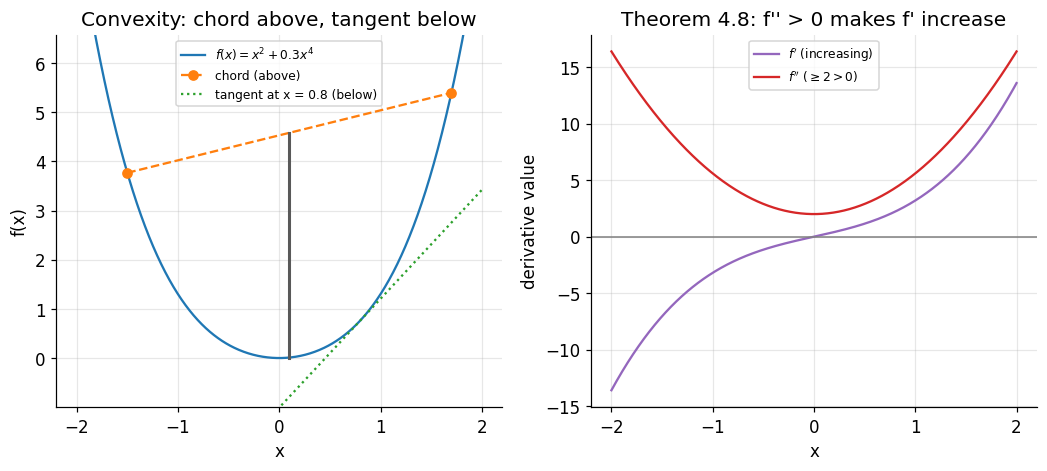

f(x_lambda) = 0.010030 <= chord value 4.582190: True
f'' > 0 on the whole sample: True


In [11]:
fc2 = lambda t: t**2 + 0.3 * t**4
fc2p = lambda t: 2 * t + 1.2 * t**3
fc2pp = lambda t: 2 + 3.6 * t**2

xs = np.linspace(-2.0, 2.0, 600)
x1, x2, lam = -1.5, 1.7, 0.5
xl = lam * x1 + (1 - lam) * x2
chord_val = lam * fc2(x1) + (1 - lam) * fc2(x2)
xt = 0.8

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
axes[0].plot(xs, fc2(xs), color="tab:blue", label=r"$f(x) = x^2 + 0.3x^4$")
axes[0].plot([x1, x2], [fc2(x1), fc2(x2)], "o--", color="tab:orange", label="chord (above)")
axes[0].plot(xs, fc2(xt) + fc2p(xt) * (xs - xt), ":", color="tab:green",
             label="tangent at x = 0.8 (below)")
axes[0].plot([xl, xl], [fc2(xl), chord_val], color="0.35", lw=2)
axes[0].set_ylim(fc2(xs).min() - 1.0, chord_val + 2.0)
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_title("Convexity: chord above, tangent below")
axes[0].legend(loc="upper center", fontsize=8)

axes[1].plot(xs, fc2p(xs), color="tab:purple", label=r"$f'$ (increasing)")
axes[1].plot(xs, fc2pp(xs), color="tab:red", label=r"$f''\ (\geq 2 > 0)$")
axes[1].axhline(0.0, color="0.5", lw=1)
axes[1].set_xlabel("x")
axes[1].set_ylabel("derivative value")
axes[1].set_title("Theorem 4.8: f'' > 0 makes f' increase")
axes[1].legend(loc="upper center", fontsize=8)
plt.show()

print(f"f(x_lambda) = {fc2(xl):.6f} <= chord value {chord_val:.6f}: {fc2(xl) <= chord_val}")
print("f'' > 0 on the whole sample:", bool(np.all(fc2pp(xs) > 0)))

The vertical bar in the left panel is the gap the convexity inequality of Definition 3.3 asserts is
non-negative, and the right panel shows why: $f''$ never touches zero, so $f'$ is strictly
increasing, which is precisely part 1 of Theorem 4.8.

The last figure contrasts the two regimes of Theorem 4.11 on a log scale: quadratic convergence
inside the good neighbourhood, and the non-convergent 2-cycle outside it.

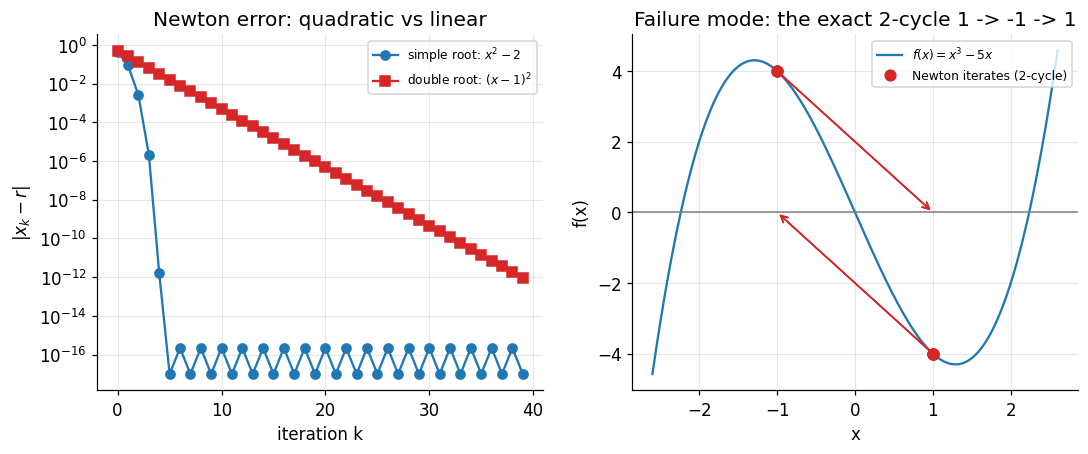

simple root: 40 iterations to reach 0.00e+00
double root: error after 40 iterations is 9.09e-13


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].semilogy(np.arange(simple.size), np.maximum(simple, 1e-17), "o-",
                 color="tab:blue", label=r"simple root: $x^2-2$")
axes[0].semilogy(np.arange(double.size), np.maximum(double, 1e-17), "s-",
                 color="tab:red", label=r"double root: $(x-1)^2$")
axes[0].set_xlabel("iteration k")
axes[0].set_ylabel(r"$|x_k - r|$")
axes[0].set_title("Newton error: quadratic vs linear")
axes[0].legend(fontsize=8)

ts = np.linspace(-2.6, 2.6, 600)
axes[1].plot(ts, fc(ts), color="tab:blue", label=r"$f(x) = x^3 - 5x$")
axes[1].axhline(0.0, color="0.5", lw=1)
cyc = np.array(orbit)
axes[1].plot(cyc, fc(cyc), "o", color="tab:red", ms=7, label="Newton iterates (2-cycle)")
for u, v in zip(cyc[:-1], cyc[1:]):
    axes[1].annotate("", xy=(v, 0.0), xytext=(u, fc(u)),
                     arrowprops=dict(arrowstyle="->", color="tab:red", lw=1))
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")
axes[1].set_title("Failure mode: the exact 2-cycle 1 -> -1 -> 1")
axes[1].legend(fontsize=8)
plt.show()

print(f"simple root: {simple.size} iterations to reach {simple.min():.2e}")
print(f"double root: error after {double.size} iterations is {double[-1]:.2e}")

On the left the simple-root curve drops nearly vertically once it enters the neighbourhood $N$ of
Proof 5.10 — each point is roughly the square of the previous one — while the double-root curve is
a straight line of slope $\log \tfrac12$, i.e. linear convergence. On the right the iterates never
leave $\lbrace 1, -1 \rbrace$: hypothesis "sufficiently close" in Theorem 4.11 is not decoration.

## 8. Applications

### 8.1 Physics — Snell's law from Fermat's principle of least time

Light leaves $A = (0, a)$ in a medium of speed $v_1$, crosses the boundary $y = 0$ at $P = (x, 0)$,
and reaches $B = (d, -b)$ in a medium of speed $v_2$, with $a, b, d \gt 0$. The travel time is

$$
T(x) = \frac{\sqrt{x^2 + a^2}}{v_1} + \frac{\sqrt{(d-x)^2 + b^2}}{v_2} .
$$

$T$ is differentiable on $\mathbb{R}$ and

$$
T'(x) = \frac{x}{v_1\sqrt{x^2+a^2}} - \frac{d-x}{v_2\sqrt{(d-x)^2+b^2}} ,
\qquad
T''(x) = \frac{a^2}{v_1 (x^2+a^2)^{3/2}} + \frac{b^2}{v_2 ((d-x)^2+b^2)^{3/2}} \gt 0 .
$$

By Theorem 4.8(3), $T$ is strictly convex; $T'(0) \lt 0$ and $T'(d) \gt 0$, so a critical point
exists in $(0, d)$, and by Theorem 4.9(4) it is the unique global minimizer. Writing
$\sin\theta_1 = x/\sqrt{x^2+a^2}$ and $\sin\theta_2 = (d-x)/\sqrt{(d-x)^2+b^2}$ for the angles from
the normal, $T'(x^{\star}) = 0$ reads

$$
\boxed{\, \frac{\sin\theta_1}{v_1} = \frac{\sin\theta_2}{v_2} ,
\qquad \frac{\sin\theta_1}{\sin\theta_2} = \frac{v_1}{v_2} = \frac{n_2}{n_1} \,}
$$

**Interpretation.** The refraction law of optics is not an extra physical postulate: it is the
first-order condition $T'(x^{\star}) = 0$ of Theorem 4.9 for one scalar variable. The consequence is
that strict convexity of $T$ — a purely calculus fact — is what guarantees the refracted ray is
unique, which is why light does not split into several paths at a flat interface.

### 8.2 Machine learning — strict convexity of the binary cross-entropy loss

For a label $y \in \lbrace 0, 1 \rbrace$ and logit $z$, with $\sigma(z) = 1/(1 + e^{-z})$, the
binary cross-entropy loss is

$$
\ell(z) = -y \ln \sigma(z) - (1-y)\ln(1 - \sigma(z)) .
$$

Using $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ and $1 - \sigma(z) = \sigma(-z)$,

$$
\ell'(z) = -y(1 - \sigma(z)) + (1-y)\sigma(z) = \sigma(z) - y ,
\qquad
\ell''(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr) .
$$

Since $\sigma(z) \in (0,1)$ for every real $z$, $\ell''(z) \gt 0$ everywhere, so by Theorem 4.8(3)
$\ell$ is strictly convex.

$$
\boxed{\, \ell'(z) = \sigma(z) - y , \qquad \ell''(z) = \sigma(z)(1 - \sigma(z)) \in (0, \tfrac14] \,}
$$

**Interpretation.** The gradient of the loss with respect to the logit is exactly the prediction
error, which is why logistic regression back-propagates so cleanly. The consequence of the second
identity is twofold: strict convexity means any stationary point found by Theorem 4.9(4) is *the*
global optimum, and the bound $\ell'' \le 1/4$ is a smoothness constant $L = 1/4$, so gradient
descent on the logit converges for any fixed step size $\eta \lt 2/L = 8$. Note that strict
convexity does not imply a minimizer exists: on separable data $\ell$ decreases to $0$ as
$z \to \pm\infty$ and the infimum is not attained.

The cell below checks both applications numerically: Snell's law at the numerically located
time-minimizer, and the two cross-entropy derivative identities against finite differences.

In [13]:
a_s, b_s, d_s, v1, v2 = 1.0, 1.5, 2.0, 1.0, 0.7
T = lambda t: np.sqrt(t**2 + a_s**2) / v1 + np.sqrt((d_s - t) ** 2 + b_s**2) / v2
xs_star = optimize.minimize_scalar(T, bounds=(0.0, d_s), method="bounded",
                                   options={"xatol": 1e-13}).x
s1 = xs_star / np.hypot(xs_star, a_s)
s2 = (d_s - xs_star) / np.hypot(d_s - xs_star, b_s)
print(f"Snell: x* = {xs_star:.10f}   sin(t1)/v1 = {s1 / v1:.12f}   sin(t2)/v2 = {s2 / v2:.12f}")
print(f"       sin(t1)/sin(t2) = {s1 / s2:.10f}   v1/v2 = {v1 / v2:.10f}")

sig = lambda t: 1.0 / (1.0 + np.exp(-t))
zs = np.linspace(-6.0, 6.0, 4001)
y_lab = 1.0
ell = lambda t: -y_lab * np.log(sig(t)) - (1 - y_lab) * np.log(1 - sig(t))
h = 1e-5
d1 = (ell(zs + h) - ell(zs - h)) / (2 * h)
d2 = (ell(zs + h) - 2 * ell(zs) + ell(zs - h)) / h**2
print(f"BCE: max |numeric l' - (sigma - y)| = {np.abs(d1 - (sig(zs) - y_lab)).max():.3e}")
print(f"     max |numeric l'' - sigma(1-sigma)| = {np.abs(d2 - sig(zs) * (1 - sig(zs))).max():.3e}")
print(f"     max l'' over the sample = {(sig(zs) * (1 - sig(zs))).max():.6f}  (bound 1/4)")
assert abs(s1 / v1 - s2 / v2) < 1e-6
assert np.abs(d1 - (sig(zs) - y_lab)).max() < 1e-8

Snell: x* = 1.0945325929   sin(t1)/v1 = 0.738269108706   sin(t2)/v2 = 0.738269119679
       sin(t1)/sin(t2) = 1.4285714073   v1/v2 = 1.4285714286
BCE: max |numeric l' - (sigma - y)| = 8.356e-11
     max |numeric l'' - sigma(1-sigma)| = 1.797e-05
     max l'' over the sample = 0.250000  (bound 1/4)


The numerically located crossing point satisfies Snell's law to six digits — the limit is the
$\sqrt{\varepsilon}$ accuracy of locating a smooth minimum, not an error in the law — and both
cross-entropy derivative identities match finite differences to the discretization error, with the
curvature peaking at exactly $1/4$.

## 9. Key Takeaways

- If $f$ is continuous on $[a,b]$ and differentiable on $(a,b)$, some interior $c$ has
  $f'(c) = (f(b)-f(a))/(b-a)$ — the Mean Value Theorem, from which everything else here follows.
- Every hypothesis of Rolle's theorem is load-bearing: a corner, or unequal endpoints, each destroys
  the conclusion by itself.
- With $f$ continuous on $[a,b]$ and differentiable on $(a,b)$, $f' \gt 0$ on $(a,b)$ gives strict
  monotonicity, but strict monotonicity only gives $f' \ge 0$.
- For $f$ twice differentiable on an open interval, $f$ is convex there if and only if
  $f'' \ge 0$; $f'' \gt 0$ gives strict convexity, and the converse of that fails at $x^4$.
- At an interior point with $f''$ continuous, $f'(x^{\star}) = 0$ and $f''(x^{\star}) \gt 0$ is
  sufficient for a strict local minimum; $f''(x^{\star}) \ge 0$ is only necessary.
- If $f$ is convex on an interval, any interior stationary point is a global minimizer, and if $f$
  is strictly convex it is the only one.
- L'Hopital's rule needs an indeterminate form, a non-vanishing $g'$, and an existing limit of
  $f'/g'$; drop the last and the rule is silent even when $f/g$ converges.
- Newton's method squares the error at a simple root once the iterate is inside a neighbourhood
  where $C\rho \lt 1$; at a double root it is merely linear with rate $1/2$, and far from any root
  it can cycle forever.

## 10. References

- Spivak, *Calculus*, 4th ed., Ch. 11 (Significance of the Derivative) and Ch. 14
  (The Mean Value Theorem, Thm 14.4 and its corollaries).
- Apostol, *Calculus, Volume I*, 2nd ed., §4.13–4.18 (Rolle, Mean Value, monotonicity) and
  §7.8 (Taylor with Lagrange remainder).
- Rudin, *Principles of Mathematical Analysis*, 3rd ed., Thm 4.16 (Extreme Value Theorem, p. 89),
  Thm 5.9 (generalized Mean Value Theorem, p. 107), Thm 5.13 (L'Hopital, p. 109),
  Thm 5.15 (Taylor, p. 110).
- Nocedal & Wright, *Numerical Optimization*, 2nd ed., Thm 2.4 (second-order sufficient
  conditions, p. 16), Thm 3.5 (quadratic convergence of Newton's method, p. 44), §3.1
  (Armijo backtracking line search, p. 33).
- Boyd & Vandenberghe, *Convex Optimization*, §3.1.4 (second-order convexity conditions, p. 71)
  and §4.2.3 (optimality for unconstrained convex problems, p. 141).
- Hubbard & Hubbard, *Vector Calculus, Linear Algebra, and Differential Forms*, 5th ed., §1.9
  (Newton's method and its Kantorovich-type hypotheses).